In [47]:
import numpy as np
import matplotlib.pyplot as plt
import ultra_user.data_access.MyUltraFile as MyUltraFile
import ultra_user.culling.UltraCull0 as UltraCull0
import spiceypy

rootDir = "/Volumes/Extreme SSD/imap_data/imap"
# initialize spice (for time conversions)
spiceypy.furnsh(rootDir+'/spice/sclk/imap_sclk_0054.tsc')
spiceypy.furnsh(rootDir+'/spice/lsk/naif0012.tls')
# read in some example data from an arbitrary repointing. Note that these are basically just CDFlib structures
repoint = 47
de = MyUltraFile.L1Bde(repoint,rootDir=rootDir).data
xspin = MyUltraFile.L1Bxspin(repoint,rootDir=rootDir).data
l1c = MyUltraFile.L1C(repoint,rootDir=rootDir).data
status = MyUltraFile.L1Bstatus(repoint,rootDir=rootDir).data


# Ultra Culling Algorithm Prototypes
In this notebook we outline prototype algorithms for culling the IMAP/Ultra data for heliospheric mapping. The prototype algorithms themselves are implemented in the python class *UltraCull0* which can be used as a model for SDC implementation and validation.

The overall assumption made here is that the object of the Ultra observations, ENAs produced in the heliosheath, varies on the timescale of several months, so that during a single pointing (~1 day) the source we are looking for has negligible spin to spin variation. That is, the data acceptable as an outer heliospheric source should appear as time invariant over the course of a pointing.

The culling of the data is complicated by several factors
- the number of counts/spin in a particular energy channel is small
- the instrument settings, particularly the deflection plate voltages can change
- particle populations with energies that exceed the deflection plate rejection can cause events at lower energies through a variety of mechanisms

The algorithms here seek to address these difficulties.

In practice, we propose this culling to be implemented through extension of the **Extended Spin Table**.  Each spin within a pointing should be marked with a boolean value, events the occur during acceptable spins can be used for processing into Level 1C maps.  The bulk of this document describes the construction of such a mask for each pointing.

## Energy and Spin Bins for Culling
In order to study the statistics of the measurements, bins in time and energy must be broad enough for a suitable number of counts to be acquired. Because the culling mask is being constructed for the purpose of Level 1C production, we chose to use energy ranges that are combined from the Level 1C bins defined in the data. Here we use the Level 1C data to defined useful energy ranges for culling.


In [48]:

l1c_ebins = np.transpose([l1c['energy_bin_geometric_mean']-l1c['energy_delta_minus'],
             l1c['energy_bin_geometric_mean']+l1c['energy_delta_plus']])

base_ebin = 4
n_1cbins=8
ebin_start = np.arange(base_ebin,len(l1c_ebins),n_1cbins,dtype=int)
ebin_end = np.append(ebin_start[1:]-1,len(l1c_ebins)-1)

eranges = np.ndarray((2,len(ebin_start)))
for ic in range(len(ebin_start)):
    eranges[:,ic] = [l1c_ebins[ebin_start[ic]][0],l1c_ebins[ebin_end[ic]][1]]
energy_ranges = np.transpose(eranges)
for ic in range(len(ebin_start)):
    de_over_e = (energy_ranges[ic,1] - energy_ranges[ic,0])/np.sqrt(energy_ranges[ic,1] * energy_ranges[ic,0])
    print(f"Channel {ic}: {energy_ranges[ic,0]:.2f} - {energy_ranges[ic,1]:.2f} (dE/E = {de_over_e})")

Channel 0: 4.60 - 10.27 (dE/E = 0.8249334636854446)
Channel 1: 10.27 - 23.44 (dE/E = 0.8490359160850197)
Channel 2: 23.44 - 52.21 (dE/E = 0.8222260819677584)
Channel 3: 52.21 - 116.28 (dE/E = 0.8222265605798472)
Channel 4: 116.28 - 258.95 (dE/E = 0.8222271970647618)
Channel 5: 258.95 - 316.33 (dE/E = 0.20050112112239826)


Even with these broad energy bins, the number of counts/spin is still small, i.e., just a few counts/spin or so. For useful statistics, we combine the data into groups of 20 spins (~300 seconds).

Both the energy and the temporal binning are subject to tuning, although in the analysis that follows, we adopt the above bin definitions. The following culling prototype code uses these defaults - this sets up the data set for analysis, the details of which will be described below

In [49]:
repointings = np.append(range(27,99),range(125,136))
cullData = dict()
ecull = dict()
scull = dict()
vcull = dict()
cnt_sum = dict()
for repoint in repointings:
    cullData[repoint] = UltraCull0.UltraCull0(repoint,energy_ranges,rootDir=rootDir,spin_range=20)
    cnt_sum[repoint] = cullData[repoint].get_count_summary()
    vcull[repoint] = cullData[repoint].voltage_cull()
    ecull[repoint] = cullData[repoint].high_energy_cull()
    scull[repoint] = cullData[repoint].statistical_cull()


## Deflection Plate Voltage Cull
When the deflection plate voltage drops (or is turned off), the instrument is open to ion backgrounds.  For this purpose, we seek to eliminate spin bins where the average voltage on the plates drops by a given threshold (currently set at 3000). Since the periods of low voltage are known from the data and identify a state of the instrument that is likely to have increased ion background, this is the first cull that should be applied.

As a simple example of this, during repointing 37, the high voltage was turned off for a short time, and ion background dominated the signal during this period.   

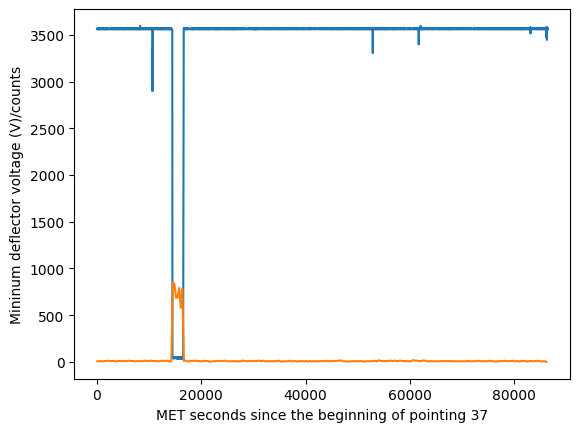

In [50]:
repoint = 37
cbins = cullData[repoint].center_spin()
status = cullData[repoint].status
minv=np.minimum(status['rightdeflection_v'], status['leftdeflection_v'])
t0=min(status['shcoarse'])


plt.plot(status['shcoarse']-t0,minv,label='minimum deflector voltage')
plt.plot(cbins['center_time']-t0,cullData[repoint].get_count_summary()[:,1],label='Counts in Energy Bin 1')
plt.xlabel('MET seconds since the beginning of pointing 37')
plt.ylabel('Mininum deflector voltage (V)/counts')
#plt.xlim(13000,18000)
plt.show()


Concetrating on the period of the voltage drop

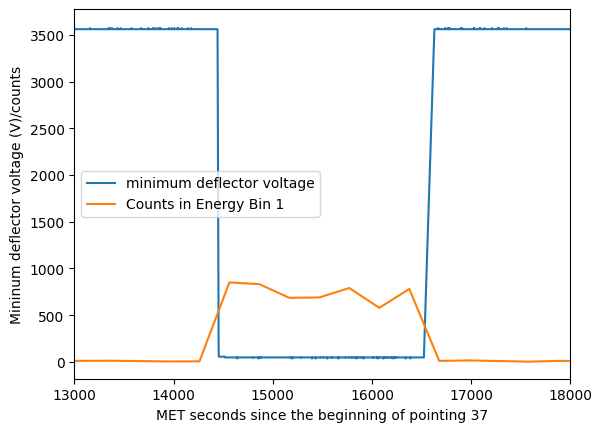

In [51]:

plt.plot(status['shcoarse']-t0,minv,label='minimum deflector voltage')
plt.plot(cbins['center_time']-t0,cullData[repoint].get_count_summary()[:,1],label='Counts in Energy Bin 1')
plt.xlabel('MET seconds since the beginning of pointing 37')
plt.ylabel('Mininum deflector voltage (V)/counts')
plt.xlim(13000,18000)
plt.legend()
plt.show()

Clearly, the cull should remove any periods of data like this. The plot below shows the result of the voltage cull for repoint 37, energy channel 1.

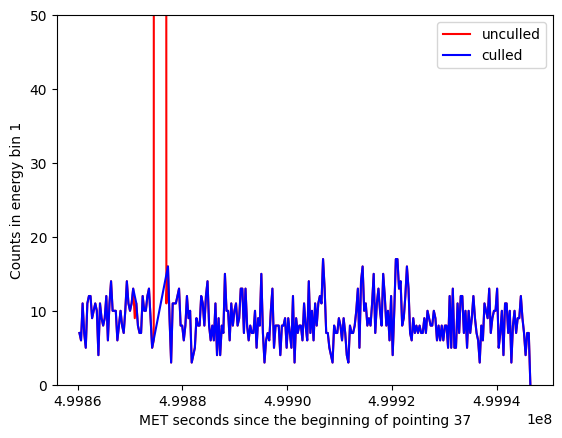

In [52]:
ii = np.nonzero(vcull[repoint]['binMask'])[0]
plt.plot(cbins['center_time'],cullData[repoint].get_count_summary()[:,1],'r',label='unculled')
plt.plot(cbins['center_time'][ii],cullData[repoint].get_count_summary()[ii,1],'b',label='culled')
plt.xlabel('MET seconds since the beginning of pointing 37')
plt.ylabel('Counts in energy bin 1')
plt.ylim(0,50)
plt.legend()

Expanding the analysis to the larger pre-phase E data set, we show the overall results of the voltage cull on the bin 1 (~10 - 23 keV) energy bin. In this plot the green us the culled data set:

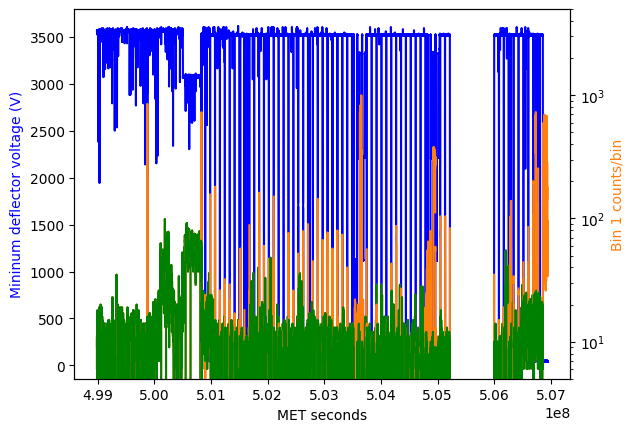

In [53]:
fig,ax1 = plt.subplots()
c1 = 'b'
ax1.set_xlabel('MET seconds')
ax1.set_ylabel('Mininum deflector voltage (V)', color=c1)
ax2 = ax1.twinx()
c2 = 'tab:orange'
ax2.set_ylabel('Bin 1 counts/bin', color=c2)  # we already handled the x-label with ax1
ax2.set_yscale('log')
ax2.set_ylim(5,5000)

for repoint in repointings:
    cbins = cullData[repoint].center_spin()
    status = cullData[repoint].status
    minv=np.minimum(status['rightdeflection_v'], status['leftdeflection_v'])

    ax1.plot(status['shcoarse'],minv,c1,label='minimum deflector voltage')
    ax2.plot(cbins['center_time'],cullData[repoint].get_count_summary()[:,1],c2,label='Counts in Energy Bin 1')
    ii = np.nonzero(vcull[repoint]['binMask'])[0]
    ax2.plot(cbins['center_time'][ii], cullData[repoint].get_count_summary()[ii, 1], 'g', label='culled')
plt.show()


## Culling Based on Rate in High Energy Channels
During the first month of operations, a storm of energetic particles washed over IMAP. The high particle fluxes were seen clearly in the higher energy channels (above 100 kev) where the deflection plates are not effective. At very high count rates in the high energy channels, the lower energy channels were obviously contaminated as well. The plot below shows the count rates during the first weeks of commissioning in 5 energy channels - the highest channel (4) is entirely above the deflector plate voltage and is a measure of the ambient particle environment.

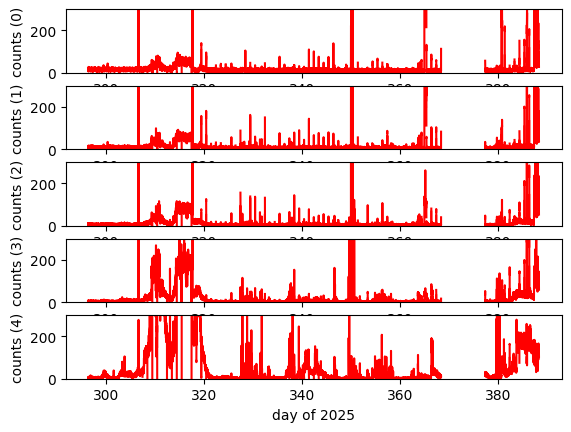

In [54]:

t0 = spiceypy.sce2t(-43,spiceypy.str2et("2025-01-01T00"))*2.e-5 +1#magic number time conversion
nch=5
fig,axs = plt.subplots(nch)
for repoint in repointings:
    tDay = (cullData[repoint].center_spin()['center_time'] - t0) / 86400
    for ech in range(nch):
        axs[ech].plot(tDay, cullData[repoint].get_count_summary()[:,ech], 'r')
        axs[ech].set_ylim(0,300)
        axs[ech].set_ylabel(f"counts ({ech})")
axs[nch-1].set_xlabel("day of 2025")
plt.show()


From the plot it is clear that these intense events introduce backgrounds into the lower energies as well. The following plot demonstrates the correlation between the lower energy channels with the count rate in the 116-259 keV channel. Note that during the period from around day 303 until some time between 310 and 315, the high voltage on the deflection plates was turned down significantly.  This had a noticeable effect on channel 3, and impacts the data in the plots below.

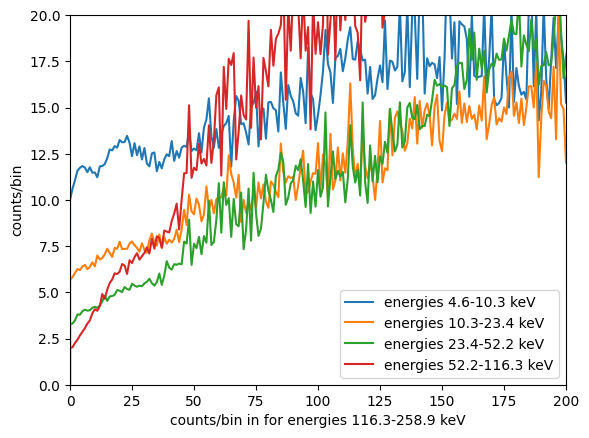

In [55]:
bigCnts = cnt_sum[repointings[0]][np.nonzero(vcull[repointings[0]]['binMask'])[0],:]
for repoint in repointings[1:]:
    bigCnts = np.concatenate((bigCnts,cnt_sum[repoint][np.nonzero(vcull[repoint]['binMask'])[0],:]))

hibins = range(0,250)
nbin=len(hibins)
cbin = 1
hbin = 4
idig = np.digitize(bigCnts[:,hbin],hibins)
cmean = np.zeros((nbin,6))
cstd = np.zeros((nbin,6))
cn = np.zeros(nbin)

for ic in range(1,nbin):
    ii = np.nonzero(idig == ic)[0]
    if len(ii) > 0:
        cn[ic]=len(ii)
        cmean[ic,:]=np.mean(bigCnts[ii,:],axis=0)
        cstd[ic,:]=np.std(bigCnts[ii,:],axis=0)

frac=np.zeros((nbin))
btot=np.sum(cn)
for ic in range(1,nbin):
    frac[ic] = np.sum(cn[0:ic])/btot

for ic in range(4):
    plt.plot(cmean[:,hbin],cmean[:,ic],label=f"energies {eranges[0,ic]:.1f}-{eranges[1,ic]:.1f} keV")
plt.xlim(0,200)
plt.ylim(0,20)
plt.xlabel(f"counts/bin in for energies {eranges[0,4]:.1f}-{eranges[1,4]:.1f} keV")
plt.ylabel("counts/bin")
plt.legend()
plt.show()


To provide context on the frequency of the rates in the high energy bin table, we show the the cumulative frequency of the count rates in these channels in the plots below. The first plot shows that roughly 80% of the spin bins have a count/spin rate of 50 or less

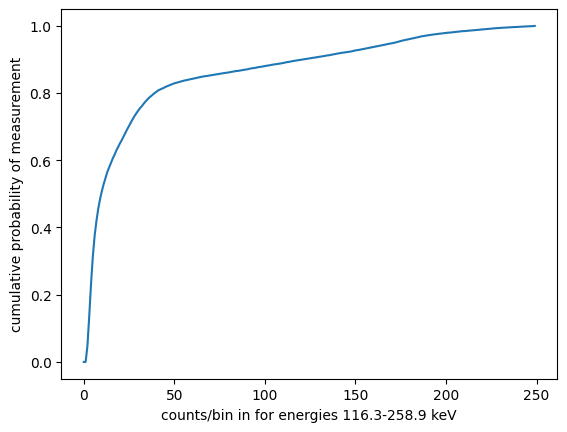

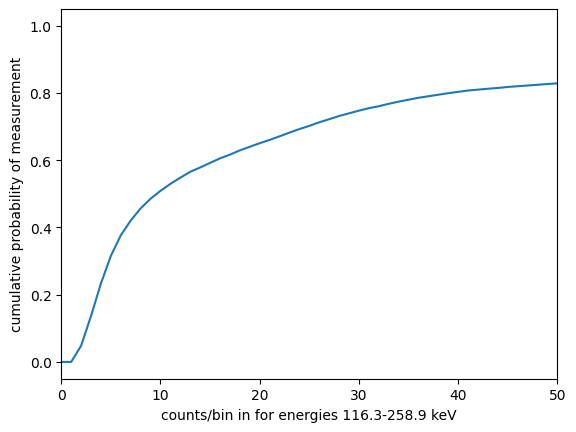

In [56]:
plt.plot(frac)
plt.xlabel(f"counts/bin in for energies {eranges[0,4]:.1f}-{eranges[1,4]:.1f} keV")
plt.ylabel("cumulative probability of measurement")
plt.show()

plt.plot(frac)
plt.xlim(0,50)
plt.xlabel(f"counts/bin in for energies {eranges[0,4]:.1f}-{eranges[1,4]:.1f} keV")
plt.ylabel("cumulative probability of measurement")
plt.show()


Although there are no obvious breakpoints in traces of the correlation plot, the slopes of the curves at high count rates are noticeably steeper than they are at low rates. The effects of the period of voltage change are clearly visible in the 52-116 keV channel. A more detailed analysis of these distribution is possible (e.g., analysis of the slopes of each of the curves, etc.) though it is likely that we will be better able to quantify the behavior with more data. For now, we take an educated guess at a cutoff based on the count rate of channel 4 at 25 counts/bin. With this threshold, roughly 75% of the lower 3 channels passes the cull.  Note that the overall pass rate will depend on the number of high count events in the future.

The plot below shows the implementation of of the 25 count/bin culling threshold on the existing dataset, where the red trace is the unculled data and the green trace shows the result of the cull

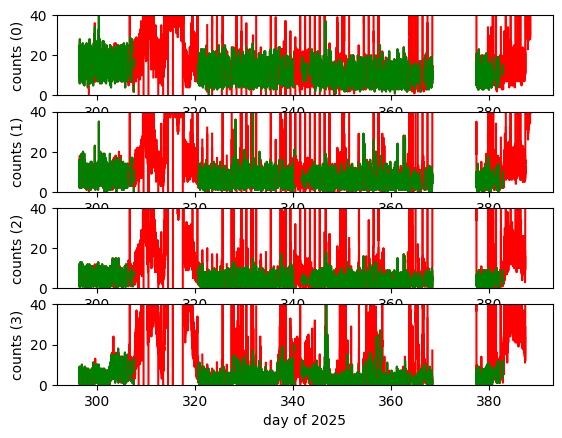

In [62]:
 
# voltage and high energy cull
t0 = spiceypy.sce2t(-43,spiceypy.str2et("2025-01-01T00"))*2.e-5 +1#magic number time conversion
nch=4
fig,axs = plt.subplots(nch)
for repoint in repointings:
    tDay = (cullData[repoint].center_spin()['center_time']-t0)/86400
    ii = np.nonzero(np.logical_and(ecull[repoint]['mask'],vcull[repoint]['binMask'] ))[0]
    for ech in range(nch):
        cnts = cullData[repoint].get_count_summary()[:,ech]
        axs[ech].plot(tDay, cnts,'r')
        if len(ii) > 0:
            color='g'
            axs[ech].plot(tDay[ii], cnts[ii], color)
for ech in range(nch):
    axs[ech].set_ylim(0,40)
    axs[ech].set_ylabel(f"counts ({ech})")
axs[nch-1].set_xlabel("day of 2025")
plt.show()


## Statistical Cull
After removing the voltage drops and the periods of high energy particles, there still appear to be time some dependence in the signal during a pointing. For each energy range in a pointing, we can calculate a mean and a standard deviation.  If the counts come from a source with no time dependence, then the calculated standard deviation should be very close to the square root of the mean (i.e., they should obey Poisson statistics). If there is time variation in the signal, then the standard deviation will be larger than the square root of the mean.

To identify periods of time dependence, we define the following algorithm applied to each energy range of each pointing:
- Caclulate the mean and standard deviation
- iterate until the (standard deviation/sqrt(mean) -1) < a threhold value (default value = 0.05)
-        remove all spin bins where (counts-mean)/(standard deviation) > 3
-        recacluate the mean and standard deviation 

In the prototype, we iterate a fixed number of times (5 by default).  If the iteration does not converge, we flag the pointing and energy range as such. Non-convergence in this case means that the data is NOT consistence with a constant  Poisson source.  In this case we could recommend that the data not be included in mapping products.
The plot below shows the full results of the cull.

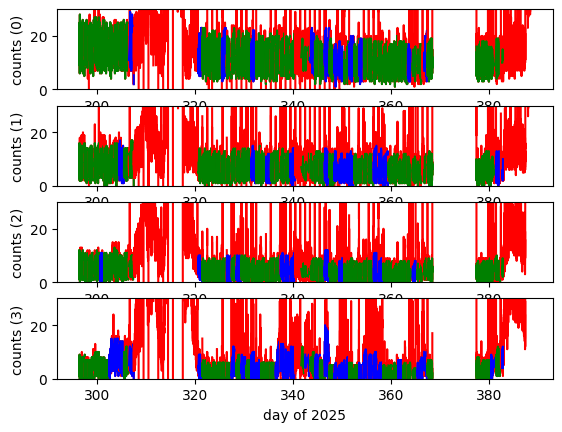

In [58]:
t0 = spiceypy.sce2t(-43,spiceypy.str2et("2025-01-01T00"))*2.e-5 +1#magic number time conversion
nch=4
fig,axs = plt.subplots(nch)
for repoint in repointings:
    tDay = (cullData[repoint].center_spin()['center_time']-t0)/86400
    for ech in range(nch):
        cnts = cullData[repoint].get_count_summary()[:,ech]
        ii = np.nonzero(cullData[repoint].currentMask['bin_mask'][ech,:])[0]
        axs[ech].plot(tDay, cnts,'r')
        if len(ii) > 0:
            color='g'
            if scull[repoint]['converge'][ech] == False:
                color='b'
            axs[ech].plot(tDay[ii], cnts[ii], color)
for ech in range(nch):
    axs[ech].set_ylim(0,30)
    axs[ech].set_ylabel(f"counts ({ech})")
axs[nch-1].set_xlabel("day of 2025")
plt.show()


For the lower three energy ranges, the cull looks successful.  The period of altered voltage, which spanned multiple pointings, likely should have been removed, but was not.

## Prototype
The prototype cull algorithms are given in *ultra_user.culling.UltraCull0* with examples of use in this notebook.  